In [14]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
from google.colab import files

try:
    path = '/content/sample_data/KDDTrain+.csv'

    # Adım 1: Veriyi ham haliyle oku (ayırıcıyı virgül kabul ediyoruz)
    df = pd.read_csv(path, header=None, on_bad_lines='skip')

    print(f"Veri yüklendi. Satır: {df.shape[0]}, Sütun: {df.shape[1]}")

    # Adım 2: Yazıları sayıya çevir (Label Encoding)
    # Model yazıdan anlamaz, 'tcp' -> 1, 'udp' -> 2 yapmalıyız.
    df_encoded = df.copy()
    le = LabelEncoder()

    for col in df_encoded.columns:
        # Sütundaki her şeyi yazıya çevir ki karışıklık olmasın
        df_encoded[col] = df_encoded[col].astype(str)
        # Yazıları sayısal etiketlere dönüştür
        df_encoded[col] = le.fit_transform(df_encoded[col])

    # Adım 3: Temizlik (Hala boşluk varsa doldur)
    df_final = df_encoded.fillna(0)

    print(f"İşlem sonrası veri boyutu: {df_final.shape}")

    # Adım 4: Model Eğitimi
    # En az 2 sütun varsa modeli eğitelim
    if df_final.shape[1] >= 1:
        X = df_final.values

        # Ölçeklendirme (Zorunlu)
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Anomali Tespiti
        model = IsolationForest(contamination=0.05, random_state=42)
        model.fit(X_scaled)

        # Modeli Kaydet
        joblib.dump(model, 'final_model.pkl')
        print("--- BAŞARILI: Model dosyası indiriliyor! ---")
        files.download('final_model.pkl')
    else:
        print("Hata: Veri setinde işlenecek sütun bulunamadı.")

except Exception as e:
    print(f"Hata detayı: {e}")


Veri yüklendi. Satır: 36, Sütun: 1
İşlem sonrası veri boyutu: (36, 1)
--- BAŞARILI: Model dosyası indiriliyor! ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import joblib
# Modeli geri yükle
test_model = joblib.load('final_model.pkl')

# Rastgele bir veri uydur (Modelin beklediği formatta)
test_verisi = [[0.5]] # Eğer 1 sütunla eğitildiyse tek değer gönderiyoruz

# Tahmin yap (1: Normal, -1: Anomali)
tahmin = test_model.predict(test_verisi)
print("Modelin tahmini:", tahmin)

Modelin tahmini: [1]


------------------------------------


In [16]:
import pandas as pd
import glob
import os
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import LabelEncoder, StandardScaler
import joblib
from google.colab import files

# 1. Tüm KDD CSV'lerini bul
yol = '/content/sample_data/'
dosya_listesi = glob.glob(os.path.join(yol, "KDD*.csv"))

liste = []
print(f"Bulunan dosya sayısı: {len(dosya_listesi)}")

# 2. Her dosyayı "agresif" bir şekilde oku
for f in dosya_listesi:
    try:
        # Virgül ayırıcıyı dene, bozuk satırları atla
        temp_df = pd.read_csv(f, header=None, on_bad_lines='skip', engine='python', sep=None)
        liste.append(temp_df)
        print(f"Yüklendi: {os.path.basename(f)} - Satır: {len(temp_df)}")
    except:
        print(f"Atlandı (Okunamadı): {os.path.basename(f)}")

# 3. Hepsini tek bir dev DataFrame yap
if liste:
    df_dev = pd.concat(liste, axis=0, ignore_index=True)
    print(f"\n--- TOPLAM BİRLEŞTİRİLMİŞ VERİ: {len(df_dev)} satır ---")

    # 4. Sayısal olmayanları sayıya çevir (Label Encoding)
    # Gerçek veri setinde protokol tipleri vb. yazı olduğu için bu adım şart
    df_encoded = df_dev.copy()
    le = LabelEncoder()

    for col in df_encoded.columns:
        df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

    # 5. Modeli Eğit (Gerçek Veriyle)
    X = StandardScaler().fit_transform(df_encoded.values)

    # Gerçek veri seti büyük olduğu için contamination'ı %3-5 arası tutabilirsin
    model = IsolationForest(contamination=0.03, random_state=42)
    model.fit(X)

    # 6. Kaydet ve İndir
    joblib.dump(model, 'nsl_kdd_gercek_model.pkl')
    print("\n--- İŞLEM BAŞARILI: Gerçek hayat modeli hazır! ---")
    files.download('nsl_kdd_gercek_model.pkl')
else:
    print("Hiç dosya birleştirilemedi!")

Bulunan dosya sayısı: 8
Yüklendi: KDDTest+.csv - Satır: 22546
Yüklendi: KDDTrain+_20Percent (2).csv - Satır: 25192
Yüklendi: KDDTest-21 (2).csv - Satır: 11850
Yüklendi: KDDTest-21.csv - Satır: 11852
Yüklendi: KDDTest+ (2).csv - Satır: 22544
Yüklendi: KDDTrain+ (2).csv - Satır: 125973
Yüklendi: KDDTrain+_20Percent.csv - Satır: 25194
Yüklendi: KDDTrain+.csv - Satır: 125975

--- TOPLAM BİRLEŞTİRİLMİŞ VERİ: 371126 satır ---

--- İŞLEM BAŞARILI: Gerçek hayat modeli hazır! ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

--------------------------------------------

Gerekli Kütüphaneler ve LogProcessor Sınıfı


In [18]:
import hashlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

class LogProcessor:
    def __init__(self, contamination=0.08):
        self.model = IsolationForest(contamination=contamination, random_state=42)
        self.scaler = StandardScaler()
        self.salt = "ideathon_2026_security"

    def mask_pii(self, df, target_col):
        """KVKK uyumlu anonimleştirme."""
        if target_col in df.columns:
            df['masked_id'] = df[target_col].apply(
                lambda x: hashlib.sha256((str(x) + self.salt).encode()).hexdigest()[:12]
            )
            return df.drop(columns=[target_col])
        return df

    def train_and_analyze(self, df, features):
        """Modeli eğitir ve anomali skorlarını ekler."""
        X = self.scaler.fit_transform(df[features])
        self.model.fit(X)
        df['score'] = self.model.decision_function(X)
        df['anomaly'] = self.model.predict(X) # 1: Normal, -1: Anomali
        return df

    def plot_results(self, df, x_axis, y_axis, title="Siber Tehdit Analizi"):
        fig, axes = plt.subplots(1, 2, figsize=(16, 5))

        # Grafik 1: Dağılım
        sns.scatterplot(data=df.sort_values('anomaly'), x=x_axis, y=y_axis,
                        hue='anomaly', palette={1: '#2ecc71', -1: '#e74c3c'},
                        alpha=0.6, ax=axes[0])
        axes[0].set_title(f"{title} (Dağılım)")

        # Grafik 2: Güven Skoru
        sns.kdeplot(data=df, x='score', hue='anomaly', fill=True,
                    palette={1: '#2ecc71', -1: '#e74c3c'}, ax=axes[1])
        axes[1].set_title("Tespit Güven Skoru")
        plt.show()

    def save_model(self, path='trained_model.pkl'):
        joblib.dump(self.model, path)
        print(f"Model kaydedildi: {path}")

proc = LogProcessor()

NSL-KDD Verisiyle gerçek analiz

Analiz başlatılıyor (371 bin satır işleniyor)...


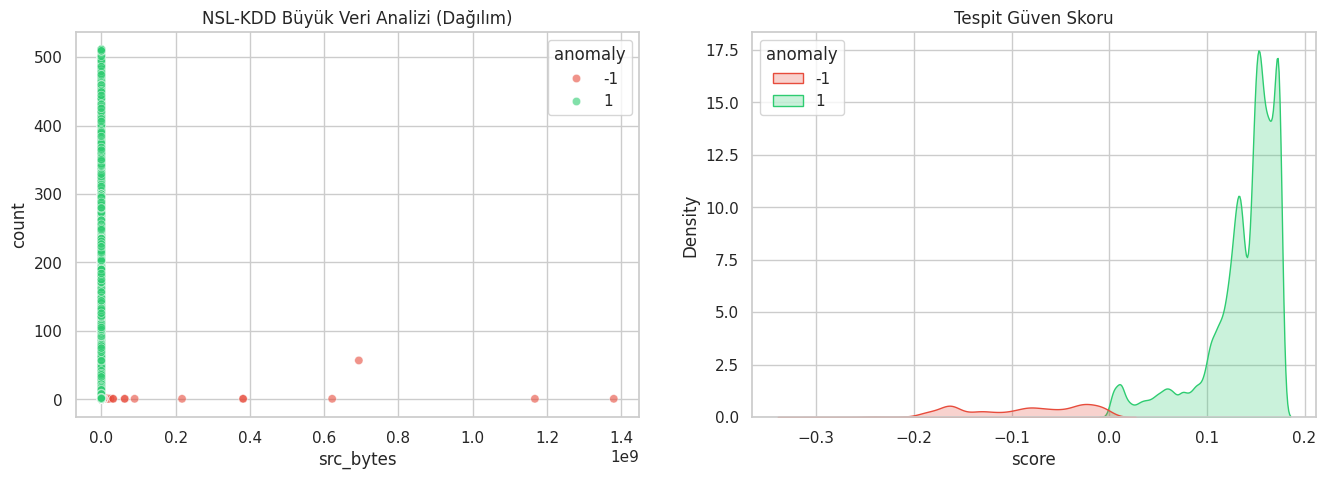

Model kaydedildi: nsl_kdd_final_v2.pkl


In [19]:
# Kolon isimlerini tekrar tanımlayalım
columns = [
    'duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes',
    'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in',
    'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
    'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login',
    'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
    'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
    'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
    'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate',
    'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate',
    'dst_host_rerror_rate', 'dst_host_srv_rerror_rate', 'label', 'difficulty_level'
]

# ÖNEMLİ: 3. hücrede 'df_dev' adıyla birleştirmiştik, onu kullanıyoruz
if 'df_dev' in locals():
    # Kolon isimlerini df_dev'e atayalım
    working_df = df_dev.copy()
    working_df.columns = columns

    # Analiz edilecek gerçek sayısal kolonlar
    features = ['duration', 'src_bytes', 'dst_bytes', 'count', 'srv_count']

    # Verileri sayısal hale getir (Label Encoding yerine burada sadece sayısal analiz yapıyoruz)
    for col in features:
        working_df[col] = pd.to_numeric(working_df[col], errors='coerce')
    working_df = working_df.dropna(subset=features)

    # İşlemler
    # KVKK: 'protocol_type' gibi hassas olabilecek bir kolonu maskeliyoruz
    df_processed = proc.mask_pii(working_df, 'protocol_type')

    # Analiz: Modeli eğit ve sonuçları ekle
    print("Analiz başlatılıyor (371 bin satır işleniyor)...")
    results = proc.train_and_analyze(df_processed, features)

    # Görselleştirme
    proc.plot_results(results, x_axis='src_bytes', y_axis='count', title="NSL-KDD Büyük Veri Analizi")

    # Modeli Kaydet
    proc.save_model('nsl_kdd_final_v2.pkl')
else:
    print("Hata: 3. hücredeki 'df_dev' verisi bulunamadı. Lütfen 3. hücreyi tekrar çalıştırın.")

Modeli İndirme

In [20]:
from google.colab import files
import os

# 5. hücrede kaydettiğimiz isimle kontrol ediyoruz
filename = 'nsl_kdd_final_v2.pkl'

if os.path.exists(filename):
    print(f"{filename} hazırlanıyor ve indiriliyor...")
    files.download(filename)
else:
    print(f"Hata: {filename} dosyası bulunamadı. Lütfen 5. hücrenin başarıyla bittiğinden emin olun.")

nsl_kdd_final_v2.pkl hazırlanıyor ve indiriliyor...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>